# A5 — Deep Learning (L1 Features)

**Aim:** evaluate LSTM/TCN on the same L1 feature table, with proper scaling and early stopping.

Run Part 1 first; we will iterate step‑by‑step.


## Part 1 — Setup (Frozen)

Load frozen features/targets, align indices, and create the 60/20/20 walk‑forward split.


In [36]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd


In [37]:
DATA_DIR = Path("../Data")
FEATURES_PATH = DATA_DIR / "processed" / "features.parquet"
TARGETS_PATH = DATA_DIR / "processed" / "targets.parquet"

features_df = pd.read_parquet(FEATURES_PATH)
targets_df = pd.read_parquet(TARGETS_PATH)

# Align on the timestamp index
features_df = features_df.sort_index()
targets_df = targets_df.sort_index()
features_df = features_df.loc[targets_df.index]

if not features_df.index.equals(targets_df.index):
    raise ValueError("Feature/target index mismatch")


In [38]:
HORIZONS = ["3h", "6h", "12h", "24h", "48h", "72h", "96h"]
target_cols = [f"target_{h}" for h in HORIZONS]
missing = [c for c in target_cols if c not in targets_df.columns]
if missing:
    raise KeyError(f"Missing target columns: {missing}")


In [39]:
# Walk-forward split: 60% / 20% / 20%
n = len(targets_df)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

idx = targets_df.index
train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

splits = {
    "train": train_idx,
    "val": val_idx,
    "test": test_idx,
}

print("Rows per split:")
for name, split_idx in splits.items():
    start = split_idx[0]
    end = split_idx[-1]
    print(f"  {name}: {len(split_idx)} rows ({start} → {end})")


Rows per split:
  train: 50789 rows (1997-01-01 00:00:00+00:00 → 2014-05-20 12:00:00+00:00)
  val: 16930 rows (2014-05-20 15:00:00+00:00 → 2020-03-05 18:00:00+00:00)
  test: 16930 rows (2020-03-05 21:00:00+00:00 → 2025-12-21 00:00:00+00:00)


**Part 1 output:** split ranges match A3/A4 (same walk‑forward periods).


## Part 2 — Sequence Windowing + Scaling

Build fixed-length sequences from the feature table, and apply train‑only scaling.


In [40]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [41]:
LOOKBACK_STEPS = 8  # 8 steps = 24h

# Fit imputer + scaler on train only
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_raw = features_df.loc[train_idx]
X_val_raw = features_df.loc[val_idx]
X_test_raw = features_df.loc[test_idx]

X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

X_train = scaler.fit_transform(X_train_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

def make_sequences(X, y, lookback):
    X_seq = []
    y_seq = []
    for i in range(lookback - 1, len(X)):
        X_seq.append(X[i - lookback + 1 : i + 1])
        y_seq.append(y[i])
    return np.stack(X_seq), np.asarray(y_seq)

seq_data = {}

for h in HORIZONS:
    y_train = targets_df.loc[train_idx, f"target_{h}"].to_numpy()
    y_val = targets_df.loc[val_idx, f"target_{h}"].to_numpy()
    y_test = targets_df.loc[test_idx, f"target_{h}"].to_numpy()

    X_train_seq, y_train_seq = make_sequences(X_train, y_train, LOOKBACK_STEPS)
    X_val_seq, y_val_seq = make_sequences(X_val, y_val, LOOKBACK_STEPS)
    X_test_seq, y_test_seq = make_sequences(X_test, y_test, LOOKBACK_STEPS)

    seq_data[h] = {
        "train": (X_train_seq, y_train_seq),
        "val": (X_val_seq, y_val_seq),
        "test": (X_test_seq, y_test_seq),
    }

print("Sequence shapes (example 24h):")
print("X_train", seq_data["24h"]["train"][0].shape)
print("y_train", seq_data["24h"]["train"][1].shape)


Sequence shapes (example 24h):
X_train (50782, 8, 29)
y_train (50782,)


## Part 3 — LSTM and TCN Models

Define sequence models, training loop, and early stopping with checkpoints.

 Why LSTM?

  - LSTM is a standard sequence model that can learn temporal dependencies across the 24h
    lookback window.
  - We take only the last hidden state (summary of the window) and map it to a single
    probability.
      -
 Why TCN?

  - TCN (Temporal Convolutional Network) uses 1‑D convolutions over time and is often
    faster and more stable than RNNs.
  - Two stacked blocks let it capture short + medium temporal patterns.

  Why these layers?

  - Conv1d: learns temporal filters across the lookback window.
  - Residual connection: stabilizes training and preserves information.
  - Dropout: regularization.
  - Final linear layer: outputs the logit.

  This is a minimal, fixed‑config setup to test if sequence modeling adds value without
  heavy tuning.



In [42]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)


In [43]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out).squeeze(-1)


In [44]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size-1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=kernel_size-1)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        y = self.conv1(x)
        y = self.relu(y)
        y = self.dropout(y)
        y = self.conv2(y)
        y = self.relu(y)
        y = self.dropout(y)
        res = x if self.downsample is None else self.downsample(x)
        # crop to match length
        if y.size(-1) > res.size(-1):
            y = y[..., -res.size(-1):]
        return y + res

class TCNClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, dropout=0.2):
        super().__init__()
        self.block1 = TCNBlock(n_features, hidden_size, dropout=dropout)
        self.block2 = TCNBlock(hidden_size, hidden_size, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq, feat) -> (batch, feat, seq)
        x = x.transpose(1, 2)
        y = self.block1(x)
        y = self.block2(y)
        y = y[:, :, -1]
        return self.fc(y).squeeze(-1)


In [45]:
def train_model(model, loaders, max_epochs=30, patience=5, lr=1e-3, ckpt_path=None):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val = None
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loaders["train"]:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in loaders["val"]:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
        val_loss = float(np.mean(val_losses))

        if best_val is None or val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
            if ckpt_path:
                torch.save(best_state, ckpt_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


## Part 4 — Train, Evaluate, and Export

Train LSTM and TCN per horizon, evaluate on val/test, save results, and export best model to ONNX.


In [46]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

def eval_model(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).float().to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()
    return {
        "roc_auc": roc_auc_score(y, probs),
        "pr_auc": average_precision_score(y, probs),
        "brier": brier_score_loss(y, probs),
    }


In [15]:
results_rows = []

BATCH_SIZE = 256
MAX_EPOCHS = 30
PATIENCE = 5
LR = 1e-3
Path("models").mkdir(exist_ok=True)


for h in HORIZONS:
    X_train_seq, y_train_seq = seq_data[h]["train"]
    X_val_seq, y_val_seq = seq_data[h]["val"]
    X_test_seq, y_test_seq = seq_data[h]["test"]

    train_ds = TensorDataset(torch.from_numpy(X_train_seq).float(), torch.from_numpy(y_train_seq).float())
    val_ds = TensorDataset(torch.from_numpy(X_val_seq).float(), torch.from_numpy(y_val_seq).float())
    test_ds = TensorDataset(torch.from_numpy(X_test_seq).float(), torch.from_numpy(y_test_seq).float())

    loaders = {
        "train": DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        "val": DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
        "test": DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    }

    n_features = X_train_seq.shape[-1]

    # LSTM
    lstm = LSTMClassifier(n_features)
    lstm = train_model(lstm, loaders, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, ckpt_path=f"models/lstm_{h}.pt")

    lstm_val = eval_model(lstm, X_val_seq, y_val_seq)
    lstm_test = eval_model(lstm, X_test_seq, y_test_seq)

    results_rows.append({
        "horizon": h,
        "model": "lstm",
        "split": "val",
        **lstm_val,
    })
    results_rows.append({
        "horizon": h,
        "model": "lstm",
        "split": "test",
        **lstm_test,
    })

    # TCN
    tcn = TCNClassifier(n_features)
    tcn = train_model(tcn, loaders, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, ckpt_path=f"models/tcn_{h}.pt")

    tcn_val = eval_model(tcn, X_val_seq, y_val_seq)
    tcn_test = eval_model(tcn, X_test_seq, y_test_seq)

    results_rows.append({
        "horizon": h,
        "model": "tcn",
        "split": "val",
        **tcn_val,
    })
    results_rows.append({
        "horizon": h,
        "model": "tcn",
        "split": "test",
        **tcn_test,
    })

    print(f"Done {h}")

results_dl_df = pd.DataFrame(results_rows)
results_dl_df


Done 3h
Done 6h
Done 12h
Done 24h
Done 48h
Done 72h
Done 96h


,horizon,model,split,roc_auc,pr_auc,brier
0,3h,lstm,val,0.939848,0.336905,0.015614
1,3h,lstm,test,0.924361,0.395443,0.019193
2,3h,tcn,val,0.940671,0.357223,0.015413
3,3h,tcn,test,0.923021,0.426094,0.017995
4,6h,lstm,val,0.906731,0.354088,0.023587
5,6h,lstm,test,0.890010,0.381010,0.028341
6,6h,tcn,val,0.908705,0.375238,0.023434
7,6h,tcn,test,0.891814,0.423982,0.026453
8,12h,lstm,val,0.842437,0.361980,0.036867
9,12h,lstm,test,0.843424,0.373897,0.046309


Done 3h
Done 6h
Done 12h
Done 24h
Done 48h
Done 72h
Done 96h


,horizon,model,split,roc_auc,pr_auc,brier
0,3h,lstm,val,0.942341,0.339909,0.015752
1,3h,lstm,test,0.924056,0.402532,0.018446
2,3h,tcn,val,0.940928,0.353630,0.015456
3,3h,tcn,test,0.921861,0.411034,0.018805
4,6h,lstm,val,0.913815,0.381163,0.022904
5,6h,lstm,test,0.894186,0.392748,0.028107
6,6h,tcn,val,0.913726,0.389885,0.022971
7,6h,tcn,test,0.893507,0.414359,0.028679
8,12h,lstm,val,0.827942,0.307552,0.038700
9,12h,lstm,test,0.829247,0.322913,0.046886


In [16]:
# Save results
results_path = Path("../Data") / "processed" / "results_dl.csv"
results_dl_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")


Saved: ../Data/processed/results_dl.csv


In [21]:
# Export best model to ONNX (example: 24h TCN)
ONNX_PATH = Path("../Data") / "processed" / "tcn_24h.onnx"

dummy = torch.randn(1, LOOKBACK_STEPS, X_train_seq.shape[-1]).to(DEVICE)
tcn = TCNClassifier(X_train_seq.shape[-1])
tcn.load_state_dict(torch.load(f"models/tcn_24h.pt", map_location=DEVICE))
tcn.eval()

torch.onnx.export(
    tcn,
    dummy,
    ONNX_PATH,
    input_names=["input"],
    output_names=["logit"],
    dynamic_axes={"input": {0: "batch"}},
    dynamo=False)

print(f"Saved ONNX: {ONNX_PATH}")


/tmp/ipykernel_50832/2934417805.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Saved ONNX: ../Data/processed/tcn_24h.onnx


/tmp/ipykernel_50832/1508672253.py:19: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if y.size(-1) > res.size(-1):


## Part 5 — DL vs Baseline Comparison

Compare LSTM/TCN against baseline and tuned results on the test split.


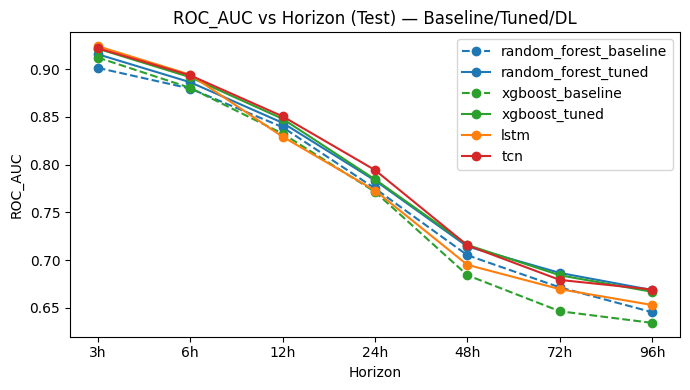

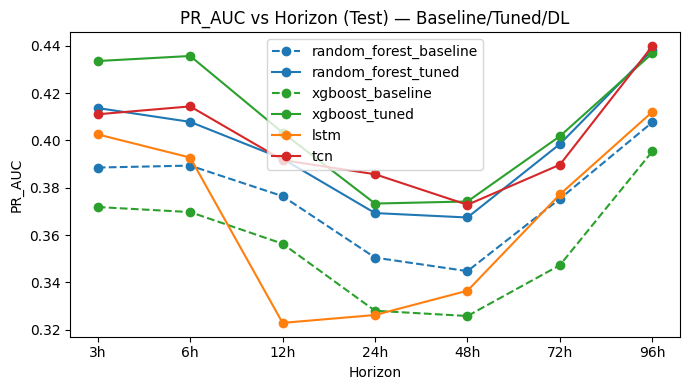

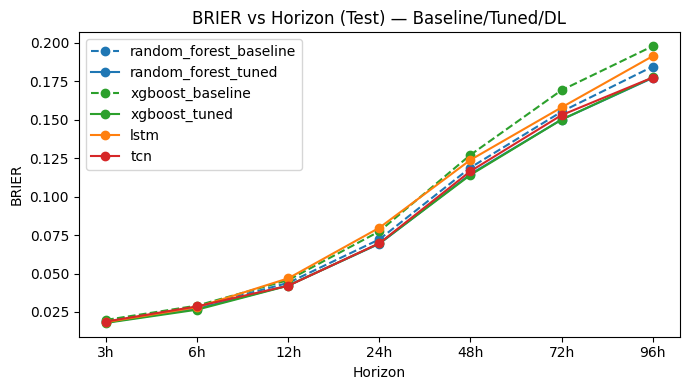

In [19]:
import matplotlib.pyplot as plt

baseline_df = pd.read_csv(Path("../Data") / "processed" / "results_baseline.csv")
tuned_df = pd.read_csv(Path("../Data") / "processed" / "results_tuned.csv")
dl_df = pd.read_csv(Path("../Data") / "processed" / "results_dl.csv")

baseline_test = baseline_df[baseline_df["split"] == "test"].copy()
tuned_test = tuned_df[tuned_df["split"] == "test"].copy()
dl_test = dl_df[dl_df["split"] == "test"].copy()

baseline_test["model"] = baseline_test["model"].replace({
    "random_forest": "random_forest_baseline",
    "xgboost": "xgboost_baseline",
})
tuned_test["model"] = tuned_test["model"].replace({
    "random_forest_tuned": "random_forest_tuned",
    "xgboost_tuned": "xgboost_tuned",
})

compare_df = pd.concat([baseline_test, tuned_test, dl_test], ignore_index=True)

metrics = ["roc_auc", "pr_auc", "brier"]
model_order = [
    "random_forest_baseline",
    "random_forest_tuned",
    "xgboost_baseline",
    "xgboost_tuned",
    "lstm",
    "tcn",
]

color_map = {
    "random_forest": "tab:blue",
    "xgboost": "tab:green",
    "lstm": "tab:orange",
    "tcn": "tab:red",
}
style_map = {
    "baseline": "--",
    "tuned": "-",
    "dl": "-",
}

def model_style(name):
    if name.startswith("random_forest"):
        return color_map["random_forest"], style_map["baseline"] if "baseline" in name else style_map["tuned"]
    if name.startswith("xgboost"):
        return color_map["xgboost"], style_map["baseline"] if "baseline" in name else style_map["tuned"]
    if name == "lstm":
        return color_map["lstm"], style_map["dl"]
    return color_map["tcn"], style_map["dl"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    for model_name in model_order:
        sub = compare_df[compare_df["model"] == model_name]
        if sub.empty:
            continue
        color, style = model_style(model_name)
        plt.plot(sub["horizon"], sub[metric], marker="o", linestyle=style, color=color, label=model_name)
    plt.title(f"{metric.upper()} vs Horizon (Test) — Baseline/Tuned/DL")
    plt.xlabel("Horizon")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()


In [20]:
# Improvement table vs baseline (test split)
baseline_rf = baseline_test[baseline_test["model"] == "random_forest_baseline"]
baseline_xgb = baseline_test[baseline_test["model"] == "xgboost_baseline"]

tuned_rf = tuned_test[tuned_test["model"] == "random_forest_tuned"]
tuned_xgb = tuned_test[tuned_test["model"] == "xgboost_tuned"]

dl_lstm = dl_test[dl_test["model"] == "lstm"]
dl_tcn = dl_test[dl_test["model"] == "tcn"]

def improvement_table(base_df, other_df, label):
    merged = base_df.merge(other_df, on="horizon", suffixes=("_base", "_other"))
    out = merged[["horizon"]].copy()
    for metric in ["roc_auc", "pr_auc", "brier"]:
        if metric == "brier":
            out[f"{metric}_delta"] = merged[f"{metric}_base"] - merged[f"{metric}_other"]
        else:
            out[f"{metric}_delta"] = merged[f"{metric}_other"] - merged[f"{metric}_base"]
    out["model"] = label
    return out

imp_rf = improvement_table(baseline_rf, tuned_rf, "random_forest_tuned")
imp_xgb = improvement_table(baseline_xgb, tuned_xgb, "xgboost_tuned")
imp_lstm = improvement_table(baseline_xgb, dl_lstm, "lstm")
imp_tcn = improvement_table(baseline_xgb, dl_tcn, "tcn")

improvement_df = pd.concat([imp_rf, imp_xgb, imp_lstm, imp_tcn], ignore_index=True)
improvement_df


,horizon,roc_auc_delta,pr_auc_delta,brier_delta,model
0,3h,0.014269,0.025130,0.000816,random_forest_tuned
1,6h,0.006630,0.018470,0.001090,random_forest_tuned
2,12h,0.004526,0.015806,0.001700,random_forest_tuned
3,24h,0.008326,0.018808,0.002860,random_forest_tuned
4,48h,0.009160,0.022662,0.004258,random_forest_tuned
5,72h,0.015138,0.023133,0.005152,random_forest_tuned
6,96h,0.023200,0.030507,0.007375,random_forest_tuned
7,3h,0.009273,0.061667,0.001927,xgboost_tuned
8,6h,0.011193,0.065938,0.002657,xgboost_tuned
9,12h,0.015484,0.046972,0.003634,xgboost_tuned


### Summary of DL vs Baseline/Tuned Results

  **ROC‑AUC vs Horizon (Ranking skill)**
  - All models degrade with horizon. (Expected)
  - TCN is consistently at the top or tied with tuned XGBoost across most
  horizons.
  - LSTM closely tracks baseline and is slightly weaker than TCN/XGB‑tuned.

  **PR‑AUC vs Horizon (Rare‑event detection)**
  - PR‑AUC dips at mid horizons and rises at long horizons (base‑rate effect).
  - TCN outperforms LSTM and is competitive with tuned XGBoost.
  - LSTM is notably weaker around 12–48h.

  **Brier vs Horizon (Calibration/Probabilities)**
  - Brier increases with horizon for all models.
  - TCN and tuned XGBoost remain the most calibrated at longer horizons.
  - LSTM is roughly baseline and sometimes slightly worse.

  **Improvement Table (Δ vs baseline)**
  - Tuned XGBoost shows the largest, most consistent gains (especially PR‑AUC
  and Brier at long horizons).
  - TCN provides small but real improvements over baseline.
  - LSTM gains are marginal and often baseline‑level.

  ### Conclusion
  Deep learning on the same L1 feature set does not deliver a breakthrough:
  **LSTM ≈ baseline**, **TCN slightly improves**, but **tuned XGBoost remains
  best overall**. This suggests the performance ceiling is mostly
  **feature‑limited**, so meaningful gains likely require upstream solar‑origin
  information rather than more complex models on the same inputs.
